<a href="https://colab.research.google.com/github/kirtiii2008/SOS/blob/main/sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

if os.path.exists("sentiment_vocab"):
    vocab = torch.load("sentiment_vocab")
else:
    vocab = {
        "<PAD>":0,
        "<UNKNOWN>":1
    }
    word_num = 2
    temp = {

    }
    for data in train_data:
        text = data["text"]
        text = text.replace("."," . ")
        text = text.replace("!"," ! ")
        text = text.replace(","," , ")
        text = text.replace("<br /><br />", "")
        words_splited = text.split()
        for word in words_splited:
            word = word.lower()
            if word not in temp:
                temp[word] = 1
            else:
                temp[word]+=1
    for words in temp:
        if temp[words] > 10 and words not in vocab:
            vocab[words] = len(vocab)
    torch.save(vocab,"sentiment_vocab")

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()

        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1 # num of layers in lstm
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        out , _ = self.lstm(x)

        return self.fc(out[:,-1,:]) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

#creating the training data into numbers
input_train_data = []
output_train_data = []

for batch in train_dataloader:
    input_text = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:200]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())

#creating testing data inot numbers
input_test_data = []
output_test_data = []

for batch in test_dataloader:
    inp = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:200]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())
            # if i%50==0:
            #     print(f"accuracy till {i+1} batch",100*(correct)/(64*i+64))

    return (100*correct/l)

#TRAINING
prev = 0
model.load_state_dict(torch.load("real_sentiment_params", map_location=device))
train_num = 10
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs)
          loss = loss_function(model_pred, labels)
          #new
          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data)
      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"train accuracy {evaluate(model=model,inp=input_train_data,out=output_train_data)}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x








epoch1 Train Loss-> 0.69515038512247 Test Accuracy -> 50.372% train accuracy 51.288
epoch2 Train Loss-> 0.6948354154291665 Test Accuracy -> 49.632% train accuracy 50.164
epoch3 Train Loss-> 0.6938761035194787 Test Accuracy -> 49.996% train accuracy 52.392
epoch4 Train Loss-> 0.6904413369305603 Test Accuracy -> 50.116% train accuracy 53.744
epoch5 Train Loss-> 0.6824142480140452 Test Accuracy -> 51.304% train accuracy 55.44
epoch6 Train Loss-> 0.6739347519167244 Test Accuracy -> 52.152% train accuracy 57.972
epoch7 Train Loss-> 0.6449235147222534 Test Accuracy -> 53.412% train accuracy 60.368
epoch8 Train Loss-> 0.625640548632273 Test Accuracy -> 52.364% train accuracy 59.236
epoch9 Train Loss-> 0.5254176387853939 Test Accuracy -> 77.608% train accuracy 83.74
epoch10 Train Loss-> 0.3427659985811814 Test Accuracy -> 81.384% train accuracy 89.368


In [ ]:
import torch
import numpy as np
from torch import nn
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

if os.path.exists("sentiment_vocab"):
    vocab = torch.load("sentiment_vocab")
else:
    vocab = {
        "<PAD>":0,
        "<UNKNOWN>":1
    }
    word_num = 2
    temp = {

    }
    for data in train_data:
        text = data["text"]
        text = text.replace("."," . ")
        text = text.replace("!"," ! ")
        text = text.replace(","," , ")
        text = text.replace("<br /><br />", "")
        words_splited = text.split()
        for word in words_splited:
            word = word.lower()
            if word not in temp:
                temp[word] = 1
            else:
                temp[word]+=1
    for words in temp:
        if temp[words] > 10 and words not in vocab:
            vocab[words] = len(vocab)
    torch.save(vocab,"sentiment_vocab")

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()

        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1 # num of layers in lstm
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        out , _ = self.lstm(x)

        return self.fc(out[:,-1,:]) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []

for batch in train_dataloader:
    input_text = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:300]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []

for batch in test_dataloader:
    inp = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:300]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())
            # if i%50==0:
            #     print(f"accuracy till {i+1} batch",100*(correct)/(64*i+64))

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []

train_num = 15
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs)
          loss = loss_function(model_pred, labels)
          #new
          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"train accuracy {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x








epoch1 Train Loss-> 0.6941649148531277 Test Accuracy -> 50.432% train accuracy 52.516%
hi
epoch2 Train Loss-> 0.689966129982258 Test Accuracy -> 50.436% train accuracy 53.312%
hi
epoch3 Train Loss-> 0.6829650424935324 Test Accuracy -> 52.692% train accuracy 57.224%
hi
epoch4 Train Loss-> 0.6696537490695944 Test Accuracy -> 52.752% train accuracy 58.784%
hi
epoch5 Train Loss-> 0.6376110069891986 Test Accuracy -> 51.576% train accuracy 58.64%
epoch6 Train Loss-> 0.6407832611552284 Test Accuracy -> 63.724% train accuracy 71.168%
hi
epoch7 Train Loss-> 0.5863968009686531 Test Accuracy -> 50.356% train accuracy 56.408%
epoch8 Train Loss-> 0.6105329339461558 Test Accuracy -> 65.008% train accuracy 72.916%
hi
epoch9 Train Loss-> 0.538260467445759 Test Accuracy -> 68.788% train accuracy 78.268%
hi
epoch10 Train Loss-> 0.5102009167299246 Test Accuracy -> 66.636% train accuracy 77.336%
epoch11 Train Loss-> 0.47838435141021945 Test Accuracy -> 76.008% train accuracy 86.132%
hi
epoch12 Train Loss-

epoch1 Train Loss-> 0.6935483011443292 Test Accuracy -> 50.52% train accuracy 52.64%
epoch2 Train Loss-> 0.690561473826923 Test Accuracy -> 51.088% train accuracy 54.604%
epoch3 Train Loss-> 0.6893346266978232 Test Accuracy -> 50.836% train accuracy 53.824%
epoch4 Train Loss-> 0.6848986098528518 Test Accuracy -> 51.492% train accuracy 53.596%
epoch5 Train Loss-> 0.6775171622595824 Test Accuracy -> 51.02% train accuracy 56.488%
epoch6 Train Loss-> 0.6542314990707065 Test Accuracy -> 51.784% train accuracy 59.032%
epoch7 Train Loss-> 0.6245118237822257 Test Accuracy -> 51.64% train accuracy 59.244%
epoch8 Train Loss-> 0.5727788061284653 Test Accuracy -> 72.056% train accuracy 79.82%
epoch9 Train Loss-> 0.41271645288028375 Test Accuracy -> 79.316% train accuracy 88.232%
epoch10 Train Loss-> 0.293390894599278 Test Accuracy -> 82.148% train accuracy 92.632%
epoch11 Train Loss-> 0.21563669492292892 Test Accuracy -> 83.208% train accuracy 95.38%
epoch12 Train Loss-> 0.16166900696180514 Test A

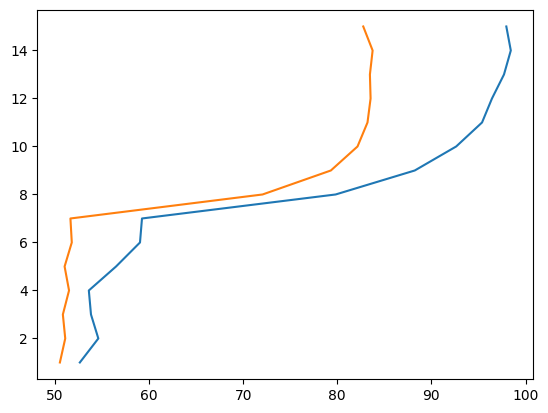

In [ ]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

if os.path.exists("sentiment_vocab"):
    vocab = torch.load("sentiment_vocab")
else:
    vocab = {
        "<PAD>":0,
        "<UNKNOWN>":1
    }
    word_num = 2
    temp = {

    }
    for data in train_data:
        text = data["text"]
        text = text.replace("."," . ")
        text = text.replace("!"," ! ")
        text = text.replace(","," , ")
        text = text.replace("<br /><br />", "")
        words_splited = text.split()
        for word in words_splited:
            word = word.lower()
            if word not in temp:
                temp[word] = 1
            else:
                temp[word]+=1
    for words in temp:
        if temp[words] > 10 and words not in vocab:
            vocab[words] = len(vocab)
    torch.save(vocab,"sentiment_vocab")

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()

        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1 # num of layers in lstm
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        out , _ = self.lstm(x)

        return self.fc(out[:,-1,:]) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []

for batch in train_dataloader:
    input_text = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:300]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []

for batch in test_dataloader:
    inp = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:300]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())
            # if i%50==0:
            #     print(f"accuracy till {i+1} batch",100*(correct)/(64*i+64))

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []

train_num = 15
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs)
          loss = loss_function(model_pred, labels)
          #new
          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"train accuracy {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x

train_acc = np.array(train_acc)
arr = np.arange(1,train_num+1)
test_acc = np.array(test_acc)
plt.plot(arr,train_acc,label="training acc")
plt.plot(arr,test_acc,label="testing acc")
plt.show()




epoch1 Train Loss-> 0.6962934863536864 Test Accuracy -> 50.012% train accuracy 50.004%
epoch2 Train Loss-> 0.6936477500459423 Test Accuracy -> 50.064% train accuracy 51.016%
epoch3 Train Loss-> 0.6912679224063063 Test Accuracy -> 50.636% train accuracy 52.844%
epoch4 Train Loss-> 0.6869845192145814 Test Accuracy -> 50.588% train accuracy 53.016%
epoch5 Train Loss-> 0.6908404930778171 Test Accuracy -> 50.856% train accuracy 52.788%
epoch6 Train Loss-> 0.6904479986261529 Test Accuracy -> 50.68% train accuracy 52.976%
epoch7 Train Loss-> 0.6837422329446544 Test Accuracy -> 50.472% train accuracy 52.64%
epoch8 Train Loss-> 0.6848491082715866 Test Accuracy -> 50.648% train accuracy 53.624%
epoch9 Train Loss-> 0.6798505351671478 Test Accuracy -> 50.724% train accuracy 53.852%
epoch10 Train Loss-> 0.6731460431347722 Test Accuracy -> 50.748% train accuracy 54.664%
epoch11 Train Loss-> 0.6626855331613585 Test Accuracy -> 50.892% train accuracy 55.712%
epoch12 Train Loss-> 0.6513230070433653 Tes

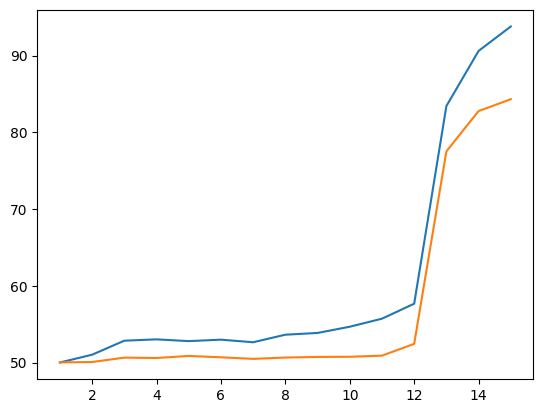

In [ ]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

if os.path.exists("sentiment_vocab"):
    vocab = torch.load("sentiment_vocab")
else:
    vocab = {
        "<PAD>":0,
        "<UNKNOWN>":1
    }
    word_num = 2
    temp = {

    }
    for data in train_data:
        text = data["text"]
        text = text.replace("."," . ")
        text = text.replace("!"," ! ")
        text = text.replace(","," , ")
        text = text.replace("<br /><br />", "")
        words_splited = text.split()
        for word in words_splited:
            word = word.lower()
            if word not in temp:
                temp[word] = 1
            else:
                temp[word]+=1
    for words in temp:
        if temp[words] > 10 and words not in vocab:
            vocab[words] = len(vocab)
    torch.save(vocab,"sentiment_vocab")

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()

        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1 # num of layers in lstm
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        out , _ = self.lstm(x)

        return self.fc(out[:,-1,:]) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []

for batch in train_dataloader:
    input_text = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:400]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []

for batch in test_dataloader:
    inp = []

    for review in batch["text"]:
        review = review.replace(".", " . ")
        review = review.replace("!", " ! ")
        review = review.replace(",", " , ")
        review = review.replace("<br /><br />", "")

        temp_inp = []
        for word in review.split()[:400]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())
            # if i%50==0:
            #     print(f"accuracy till {i+1} batch",100*(correct)/(64*i+64))

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []

train_num = 15
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs)
          loss = loss_function(model_pred, labels)
          #new
          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"train accuracy {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x

train_acc = np.array(train_acc)
arr = np.arange(1,train_num+1)
test_acc = np.array(test_acc)
plt.plot(arr,train_acc,label="training acc")
plt.plot(arr,test_acc,label="testing acc")
plt.legend(loc='upper right')
plt.show()




epoch1 Train Loss-> 0.1765165266573734 Test Accuracy -> 81.216% Train Accuracy-> 96.076%
epoch2 Train Loss-> 0.15003179584908516 Test Accuracy -> 80.5% Train Accuracy-> 95.808%
epoch3 Train Loss-> 0.1412805056823489 Test Accuracy -> 81.864% Train Accuracy-> 96.892%
epoch4 Train Loss-> 0.13931211604334204 Test Accuracy -> 81.932% Train Accuracy-> 96.76%
epoch5 Train Loss-> 0.13632888660368409 Test Accuracy -> 82.18% Train Accuracy-> 96.108%


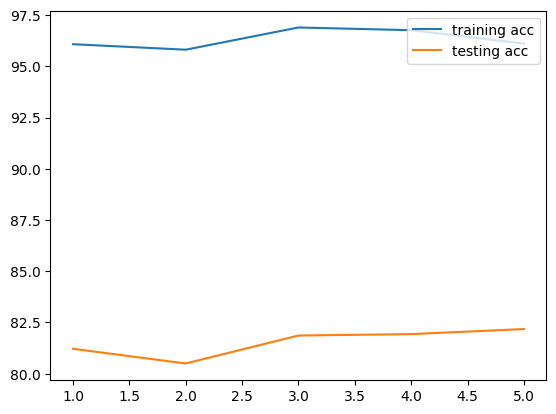

In [ ]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("stanfordnlp/imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

def build_vocab():

    if os.path.exists("sentiment_vocab"):
        vocab = torch.load("sentiment_vocab")
        return vocab
    else:
        vocab = {
            "<PAD>":0,
            "<UNKNOWN>":1
        }
        word_num = 2
        temp = {

        }
        for data in train_data:
            text = data["text"]
            text = text.replace("."," . ")
            text = text.replace("!"," ! ")
            text = text.replace(","," , ")
            text = text.replace("<br /><br />", "")
            words_splited = text.split()
            for word in words_splited:
                word = word.lower()
                if word not in temp:
                    temp[word] = 1
                else:
                    temp[word]+=1
        for words in temp:
            if temp[words] > 10 and words not in vocab:
                vocab[words] = len(vocab)
        torch.save(vocab,"sentiment_vocab")
        return vocab

vocab = build_vocab()

def preprocess(review):
    review = review.replace(".", " . ")
    review = review.replace("!", " ! ")
    review = review.replace(",", " , ")
    review = review.replace("<br /><br />", "")
    return review

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)
        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1#,  num of layers in lstm
            #dropout=0.1
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        out , (hn,cn) = self.lstm(x)
        drop_out = self.dropout(hn[-1]) # means from the taken the 2d matrix batch_size,hidden_size from last lstm layer

        return self.fc(drop_out) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []

for batch in train_dataloader:
    input_text = []

    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        for word in review.split()[:400]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []

for batch in test_dataloader:
    inp = []

    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        for word in review.split()[:400]:
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))

    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())
            # if i%50==0:
            #     print(f"accuracy till {i+1} batch",100*(correct)/(64*i+64))

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []
# if os.path.exists("real_sentiment_params"):
#   model.load_state_dict(torch.load("real_sentiment_params"))
train_num = 50 # 15+15+30+5
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs)
          loss = loss_function(model_pred, labels)
          #new
          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"Train Accuracy-> {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x

train_acc = np.array(train_acc)
arr = np.arange(1,train_num+1)
test_acc = np.array(test_acc)
plt.plot(arr,train_acc,label="training acc")
plt.plot(arr,test_acc,label="testing acc")
plt.legend(loc='upper right')
plt.show()




/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


epoch1 Train Loss-> 0.6555370479593496 Test Accuracy -> 69.004% Train Accuracy-> 71.012%
epoch2 Train Loss-> 0.5194767395706128 Test Accuracy -> 72.532% Train Accuracy-> 75.472%
epoch3 Train Loss-> 0.49341600096744037 Test Accuracy -> 78.824% Train Accuracy-> 82.472%
epoch4 Train Loss-> 0.40916730756954767 Test Accuracy -> 82.024% Train Accuracy-> 86.064%
epoch5 Train Loss-> 0.4217885646902387 Test Accuracy -> 72.876% Train Accuracy-> 74.916%
epoch6 Train Loss-> 0.37622306939890926 Test Accuracy -> 84.448% Train Accuracy-> 88.572%
epoch7 Train Loss-> 0.29237314961526706 Test Accuracy -> 85.164% Train Accuracy-> 90.388%
epoch8 Train Loss-> 0.25152812591370416 Test Accuracy -> 86.876% Train Accuracy-> 93.14%
epoch9 Train Loss-> 0.2215520490694534 Test Accuracy -> 86.444% Train Accuracy-> 92.968%
epoch10 Train Loss-> 0.18483289719923682 Test Accuracy -> 86.812% Train Accuracy-> 94.996%
epoch11 Train Loss-> 0.17340281441845856 Test Accuracy -> 87.164% Train Accuracy-> 95.6%
epoch12 Train L

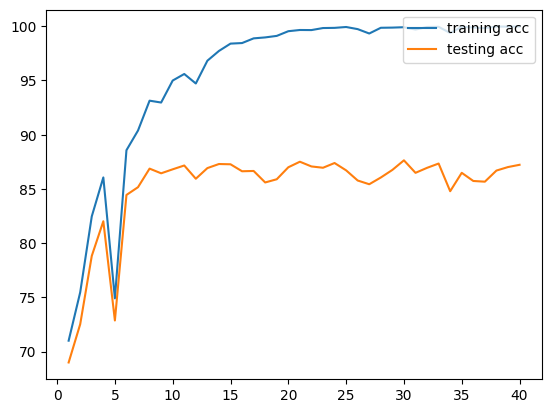

In [ ]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("stanfordnlp/imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

def build_vocab():

    if os.path.exists("sentiment_vocab"):
        vocab = torch.load("sentiment_vocab")
        return vocab
    else:
        vocab = {
            "<PAD>":0,
            "<UNKNOWN>":1
        }
        word_num = 2
        temp = {

        }
        for data in train_data:
            text = data["text"]
            text = text.replace("."," . ")
            text = text.replace("!"," ! ")
            text = text.replace(","," , ")
            text = text.replace("<br /><br />", "")
            words_splited = text.split()
            for word in words_splited:
                word = word.lower()
                if word not in temp:
                    temp[word] = 1
                else:
                    temp[word]+=1
        for words in temp:
            if temp[words] > 10 and words not in vocab:
                vocab[words] = len(vocab)
        torch.save(vocab,"sentiment_vocab")
        return vocab

vocab = build_vocab()

def preprocess(review):
    review = review.replace(".", " . ")
    review = review.replace("!", " ! ")
    review = review.replace(",", " , ")
    review = review.replace("<br /><br />", "")
    return review

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)
        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1,  #num of layers in lstm
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x,lengths):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        packed_x = pack_padded_sequence(x,lengths.cpu(),batch_first=True,enforce_sorted=False)
        out , (hn,cn) = self.lstm(packed_x)
        drop_out = self.dropout(hn[-1]) # means from the taken the 2d matrix batch_size,hidden_size from last lstm layer
        return self.fc(drop_out) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []
true_lens_train = []
for batch in train_dataloader:
    input_text = []
    temp_lens = []
    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        temp_lens.append(len(review.split()))
        for word in review.split():
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))
    true_lens_train.append(torch.tensor(temp_lens))
    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []
true_lens_test = []
for batch in test_dataloader:
    inp = []
    temp_lens = []
    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        temp_lens.append(len(review.split()))
        for word in review.split():
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))
    true_lens_test.append(torch.tensor(temp_lens))
    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out,true_lengths):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs,true_lengths[i]))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []
if os.path.exists("real_sentiment_params"):
   model.load_state_dict(torch.load("real_sentiment_params"))
#trainingggg
train_num = 10
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs,true_lens_train[j])
          loss = loss_function(model_pred, labels)

          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data,true_lengths=true_lens_test)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data,true_lengths=true_lens_train)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"Train Accuracy-> {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x

arr = np.arange(1,train_num+1)
train_acc = np.array(train_acc)
test_acc = np.array(test_acc)
plt.plot(arr,train_acc,label="training acc")
plt.plot(arr,test_acc,label="testing acc")
plt.legend(loc='upper right')
plt.show()




README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


epoch1 Train Loss-> 0.6451550182479117 Test Accuracy -> 70.26% Train Accuracy-> 72.328%
epoch2 Train Loss-> 0.5265283985515995 Test Accuracy -> 77.444% Train Accuracy-> 80.316%
epoch3 Train Loss-> 0.48206875741939104 Test Accuracy -> 79.46% Train Accuracy-> 83.008%
epoch4 Train Loss-> 0.40083855104720806 Test Accuracy -> 82.424% Train Accuracy-> 87.336%
epoch5 Train Loss-> 0.33834869889042263 Test Accuracy -> 85.26% Train Accuracy-> 89.944%
epoch6 Train Loss-> 0.28426823425857 Test Accuracy -> 86.416% Train Accuracy-> 91.324%
epoch7 Train Loss-> 0.25313128218473985 Test Accuracy -> 86.032% Train Accuracy-> 92.72%
epoch8 Train Loss-> 0.20831112565515597 Test Accuracy -> 86.36% Train Accuracy-> 94.236%
epoch9 Train Loss-> 0.17387148273913453 Test Accuracy -> 86.248% Train Accuracy-> 94.772%
epoch10 Train Loss-> 0.14535866286653235 Test Accuracy -> 87.1% Train Accuracy-> 96.52%


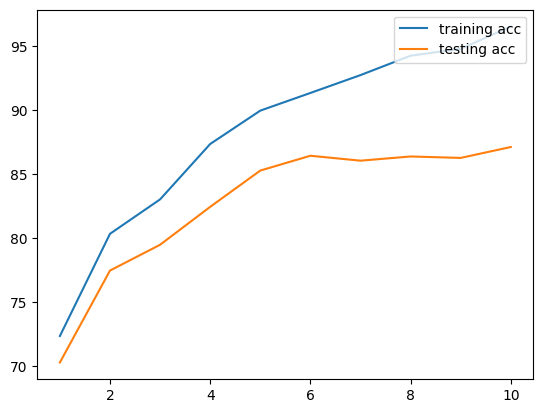

In [1]:
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
import os
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader

from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.transforms import ToTensor
import json
import time
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset

#parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = load_dataset("stanfordnlp/imdb")

train_data = DATASET["train"]
test_data  = DATASET["test"]

def build_vocab():

    if os.path.exists("sentiment_vocab"):
        vocab = torch.load("sentiment_vocab")
        return vocab
    else:
        vocab = {
            "<PAD>":0,
            "<UNKNOWN>":1
        }
        word_num = 2
        temp = {

        }
        for data in train_data:
            text = data["text"]
            text = text.replace("."," . ")
            text = text.replace("!"," ! ")
            text = text.replace(","," , ")
            text = text.replace("<br /><br />", "")
            words_splited = text.split()
            for word in words_splited:
                word = word.lower()
                if word not in temp:
                    temp[word] = 1
                else:
                    temp[word]+=1
        for words in temp:
            if temp[words] > 10 and words not in vocab:
                vocab[words] = len(vocab)
        torch.save(vocab,"sentiment_vocab")
        return vocab

vocab = build_vocab()

def preprocess(review):
    review = review.replace(".", " . ")
    review = review.replace("!", " ! ")
    review = review.replace(",", " , ")
    review = review.replace("<br /><br />", "")
    return review

#parameterss
batch_size = 64

train_dataloader = DataLoader(train_data,batch_size=64,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=False)

# torch.save(train_dataloader,"train_data_sentiment")
# torch.save(test_dataloader,"test_data_sentiment")

class Real_Sentiment(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()
        self.dropout = nn.Dropout(p=0.5)
        self.embedding = nn.Embedding(
            len(vocab),
            input_size,    # finally kitne size ki embedding chaiye
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=input_size, # the input size of each token/word here
            hidden_size=hidden_size, # arbitary genreally 2 ki powers me hoti h
            batch_first=True, # first thing is batch like we will pass something like (batch_size, sequence_length, embedding_dim) else (sequence_length, batch_size, embedding_dim)
            num_layers=1,  #num of layers in lstm
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_size,output_size)
    def forward(self,x,lengths):

        x = self.embedding(x)   # if i give it x,y it will return x,y,8
        packed_x = pack_padded_sequence(x,lengths.cpu(),batch_first=True,enforce_sorted=False)
        out , (hn,cn) = self.lstm(packed_x)
        drop_out = self.dropout(hn[-1]) # means from the taken the 2d matrix batch_size,hidden_size from last lstm layer
        return self.fc(drop_out) # because lstm outputs like batch_size ,no of timestap/len of seq , hidden_size or hn[-1] where _ = hn,cn


model = Real_Sentiment(input_size=64,hidden_size=256,output_size=1).to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


input_train_data = []
output_train_data = []
true_lens_train = []
for batch in train_dataloader:
    input_text = []
    temp_lens = []
    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        temp_lens.append(len(review.split()))
        for word in review.split():
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        input_text.append(torch.tensor(temp_inp))
    true_lens_train.append(torch.tensor(temp_lens))
    padded_input = pad_sequence(input_text, batch_first=True, padding_value=0)
    input_train_data.append(padded_input)
    output_train_data.append(torch.unsqueeze(batch["label"], 1).float())


input_test_data = []
output_test_data = []
true_lens_test = []
for batch in test_dataloader:
    inp = []
    temp_lens = []
    for review in batch["text"]:
        review = preprocess(review)
        temp_inp = []
        temp_lens.append(len(review.split()))
        for word in review.split():
            if word.lower() not in vocab:
                temp_inp.append(1)
            else:
                temp_inp.append(vocab[word.lower()])

        inp.append(torch.tensor(temp_inp))
    true_lens_test.append(torch.tensor(temp_lens))
    padded_input = pad_sequence(inp, batch_first=True, padding_value=0)
    input_test_data.append(padded_input)
    output_test_data.append(batch["label"].float())

def evaluate(model: nn.Module,inp,out,true_lengths):
    model.eval()
    l = 0
    with torch.no_grad():
        correct = 0
        for i in range(len(inp)):

            inputs = inp[i].to(device)
            labels = out[i].to(device)
            model_pred = torch.sigmoid(model(inputs,true_lengths[i]))

            model_pred_2 = (model_pred >= 0.5).float().squeeze()

            correct += (model_pred_2==labels.squeeze()).sum().item()
            l+=len(labels.squeeze())

    return (100*correct/l)

#TRAINING
prev = 0
train_acc = []
test_acc = []
if os.path.exists("real_sentiment_params"):
   model.load_state_dict(torch.load("real_sentiment_params"))
#trainingggg
train_num = 10
for i in range(train_num):
      model.train()
      start = time.time()
      loss_total = 0
      for j in range(len(input_train_data)):

          inputs = input_train_data[j].to(device)
          labels = output_train_data[j].to(device)
          model_pred = model(inputs,true_lens_train[j])
          loss = loss_function(model_pred, labels)

          loss_total+=loss.item()
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      x = evaluate(model=model,inp=input_test_data,out=output_test_data,true_lengths=true_lens_test)
      y = evaluate(model=model,inp=input_train_data,out=output_train_data,true_lengths=true_lens_train)
      train_acc.append(y)
      test_acc.append(x)

      print(f"epoch{i+1} Train Loss->",loss_total/len(input_train_data),f"Test Accuracy -> {x}%",f"Train Accuracy-> {y}%",flush=True)

      if x>prev :
          torch.save(model.state_dict(), "real_sentiment_params")
          prev = x

arr = np.arange(1,train_num+1)
train_acc = np.array(train_acc)
test_acc = np.array(test_acc)
plt.plot(arr,train_acc,label="training acc")
plt.plot(arr,test_acc,label="testing acc")
plt.legend(loc='upper right')
plt.show()


